In [284]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [285]:
task = "Task"
shovel = "Shovel"
cube = "Cube"

condition = "Condition"
c_0 = "C0"
c_1 = "C1"
c_2 = "C2"
p_0 = "P0"
p_1 = "P1"
p_2 = "P2"
conditions = [c_0, c_1, c_2, p_0, p_1, p_2]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown']

factor_device = "Device"
device_proxy = "P"
device_controller = "C"

factor_scaling = "Scaling"
scaling_none = "0"
scaling_subtle = "1"
scaling_pronounced = "2"

In [286]:
borg_cr = "How physically challenging was the experience?"
sp_fatigue = "How fatigued where you after the experience?"

general_1 = "I felt the weight of the object, while i was grabbing it"
general_2 = "The weight of the object, while i was grabbing it, felt realistic"
general_custom = [general_1, general_2]

shovel_1 = "I felt the weight of the shovel increasing when loading it"
shovel_2 = "I felt the weight of the shovel decreasing when unloading it"
shovel_3 = "After the shovel had been loaded, it required more effort to manipulate"
shovel_4 = "After the shovel had been unloaded, it required less effort to manipulate"
shovel_custom = [shovel_1, shovel_2, shovel_3, shovel_4]

fps_1 = "  My sense of being in the virtual world was like being in a real place."
fps_2 = "During the experience, I felt the virtual world was reality for me. "
fps_3 = "I felt like I was actually there in the virtual world. "
fps_4 = "I felt present in the virtual world. "
fps_5 = "I felt I could control my actions within the virtual world. "
fps_6 = "I felt the virtual world was responsive to my actions. "
fps_7 = "I felt I could move or manipulate objects easily in the virtual world. "
fps_8 = "I felt involved in the virtual world experience. "
fps_9 = "I could concentrate on the virtual activities rather than the controls to perform them. "
fps_10 = "When something happened to my virtual body, I felt it happened to my real body. "
fps = [fps_1, fps_2, fps_3, fps_4, fps_5, fps_6, fps_7, fps_8, fps_9, fps_10]

relevant_keys = [condition, task, borg_cr, sp_fatigue] + general_custom + shovel_custom + fps

In [287]:
def get_df(name):
    path = './questionnaires/' + name + '.csv'
    return pd.read_csv(path)

In [288]:
data = get_df('experiments').filter(items=relevant_keys)

data[factor_device] = data[condition].str[0]
data[factor_scaling] = data[condition].str[1:]

data.head(3)

,Condition,Task,How physically challenging was the experience?,How fatigued where you after the experience?,"I felt the weight of the object, while i was grabbing it","The weight of the object, while i was grabbing it, felt realistic",I felt the weight of the shovel increasing when loading it,I felt the weight of the shovel decreasing when unloading it,"After the shovel had been loaded, it required more effort to manipulate","After the shovel had been unloaded, it required less effort to manipulate",...,I felt like I was actually there in the virtual world.,I felt present in the virtual world.,I felt I could control my actions within the virtual world.,I felt the virtual world was responsive to my actions.,I felt I could move or manipulate objects easily in the virtual world.,I felt involved in the virtual world experience.,I could concentrate on the virtual activities rather than the controls to perform them.,"When something happened to my virtual body, I felt it happened to my real body.",Device,Scaling
0,C0,Cube,1 - Very light,1 - Very alert and fully awake,4,4,NaN,NaN,NaN,NaN,...,3,4,6,7,6,6,7,6,C,0
1,C1,Cube,2 - Light,2 - Very energetic but no longer at one’s peak,4,4,NaN,NaN,NaN,NaN,...,3,3,6,7,5,4,5,4,C,1
2,C2,Cube,1 - Very light,1 - Very alert and fully awake,3,3,NaN,NaN,NaN,NaN,...,4,5,6,5,5,5,5,4,C,2


In [289]:
def plot_boxplot(df, key, e, title, range, ax):
    task_df = df[df[task] == e]
    values = list(map(lambda x: task_df[task_df[condition] == x][key], conditions))
    ax.boxplot(values, tick_labels=conditions)
    ax.set_title('[' + e + '] ' + title)
    ax.set_ylim([range[0]-0.5, range[1]+0.5])

def plot_means(df, key, e, title, range, ax):
    task_df = df[df[task] == e]
    values = list(map(lambda x: task_df[task_df[condition] == x][key], conditions))
    means = list(map(lambda x: np.mean(x), values))
    ax.bar(conditions, means, color=colors)
    ax.set_title('[' + e + '] Mean ' + title)
    ax.set_ylim(range)

def plot_experiments(df, key, title, range):
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))

    plot_means(df, key, cube, title, range, axs[0,0])
    plot_boxplot(df, key, cube, title, range, axs[1,0])

    plot_means(df, key, shovel, title, range, axs[0,1])
    plot_boxplot(df, key, shovel, title, range, axs[1,1])

    plt.show()

In [290]:
def two_way_anova(df, e, key, title):
    print('\033[1m' + "["+e+"] " + title)
    data = df[df[task] == e]
    model = ols(key + ' ~ C('+ factor_device+') + C('+factor_scaling+') + C('+ factor_device+'):C('+factor_scaling+')', data=data).fit()
    result = sm.stats.anova_lm(model, typ=2)
    result["Significance (p<0.05)"] = result.apply(lambda x: "✅" if x["PR(>F)"] < 0.05 else "❌", axis=1)
    display(result)

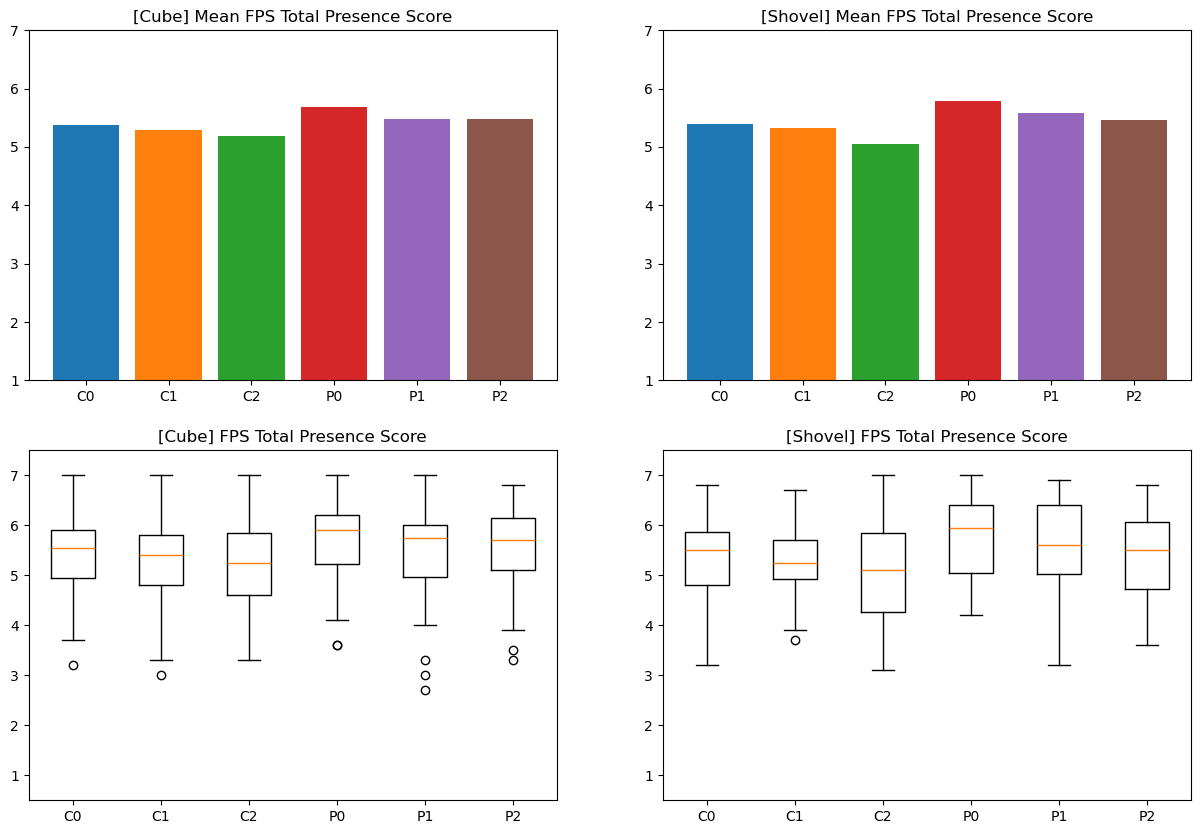

[Cube] FPS Total Presence Score


,sum_sq,df,F,PR(>F),Significance (p<0.05)
C(Device),4.426825,1.0,5.782164,0.016929,✅
C(Scaling),1.721667,2.0,1.124390,0.326514,❌
C(Device):C(Scaling),0.183889,2.0,0.120095,0.886888,❌
Residual,188.337619,246.0,NaN,NaN,❌


[Shovel] FPS Total Presence Score


,sum_sq,df,F,PR(>F),Significance (p<0.05)
C(Device),8.000040,1.0,10.743012,0.001198,✅
C(Scaling),4.818810,2.0,3.235517,0.041020,✅
C(Device):C(Scaling),0.341032,2.0,0.228981,0.795513,❌
Residual,183.189762,246.0,NaN,NaN,❌


In [291]:
fps_total = 'fps_total'
#Total Presence Score: (FPS1-10) / 10
data[fps_total] = data.apply(lambda x: 
    (x[fps_1] + x[fps_2] + x[fps_3] + x[fps_4] + x[fps_5] + x[fps_6] + x[fps_7] + x[fps_8] + x[fps_9] + x[fps_10]) / 10,
    axis = 1)

title = 'FPS Total Presence Score'
score = fps_total
plot_experiments(data, score, title, range=[1,7])
two_way_anova(data, cube, score, title)
two_way_anova(data, shovel, score, title)

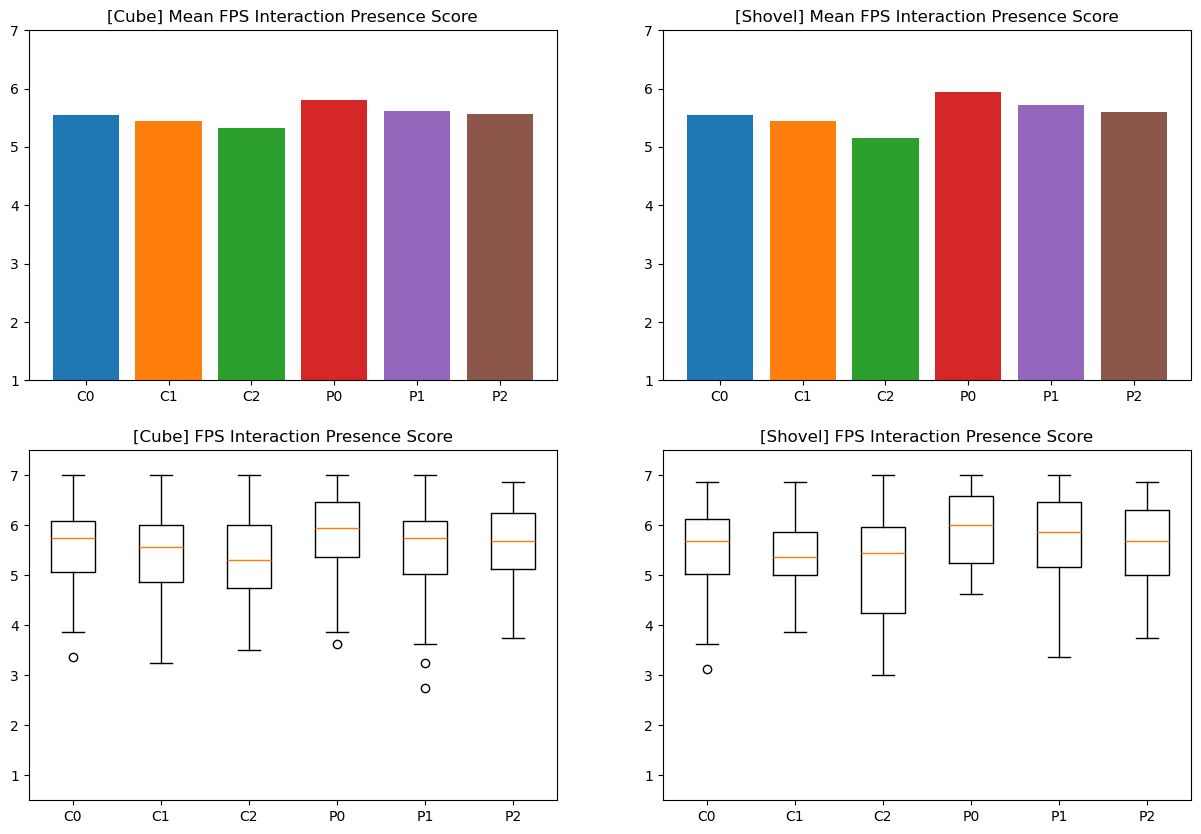

[Cube] FPS Interaction Presence Score


,sum_sq,df,F,PR(>F),Significance (p<0.05)
C(Device),3.055804,1.0,4.370056,0.037603,✅
C(Scaling),2.226314,2.0,1.591908,0.205626,❌
C(Device):C(Scaling),0.091890,2.0,0.065705,0.936423,❌
Residual,172.017857,246.0,NaN,NaN,❌


[Shovel] FPS Interaction Presence Score


,sum_sq,df,F,PR(>F),Significance (p<0.05)
C(Device),8.580357,1.0,11.554734,0.000788,✅
C(Scaling),5.972594,2.0,4.021496,0.019117,✅
C(Device):C(Scaling),0.368676,2.0,0.248238,0.780369,❌
Residual,182.675595,246.0,NaN,NaN,❌


In [292]:
fps_interaction = 'fps_interaction'
#Interaction Presence Score: (FPS-1 + FPS-2 + FPS-4 + FPS-5 + FPS-6 + FPS-7 + FPS-8 + FPS-9) / 8
data[fps_interaction] = data.apply(lambda x: 
    (x[fps_1] + x[fps_2] + x[fps_4] + x[fps_5] + x[fps_6] + x[fps_7] + x[fps_8] + x[fps_9]) / 8,
    axis = 1)

title = 'FPS Interaction Presence Score'
score = fps_interaction
plot_experiments(data, score, title, range=[1,7])
two_way_anova(data, cube, score, title)
two_way_anova(data, shovel, score, title)

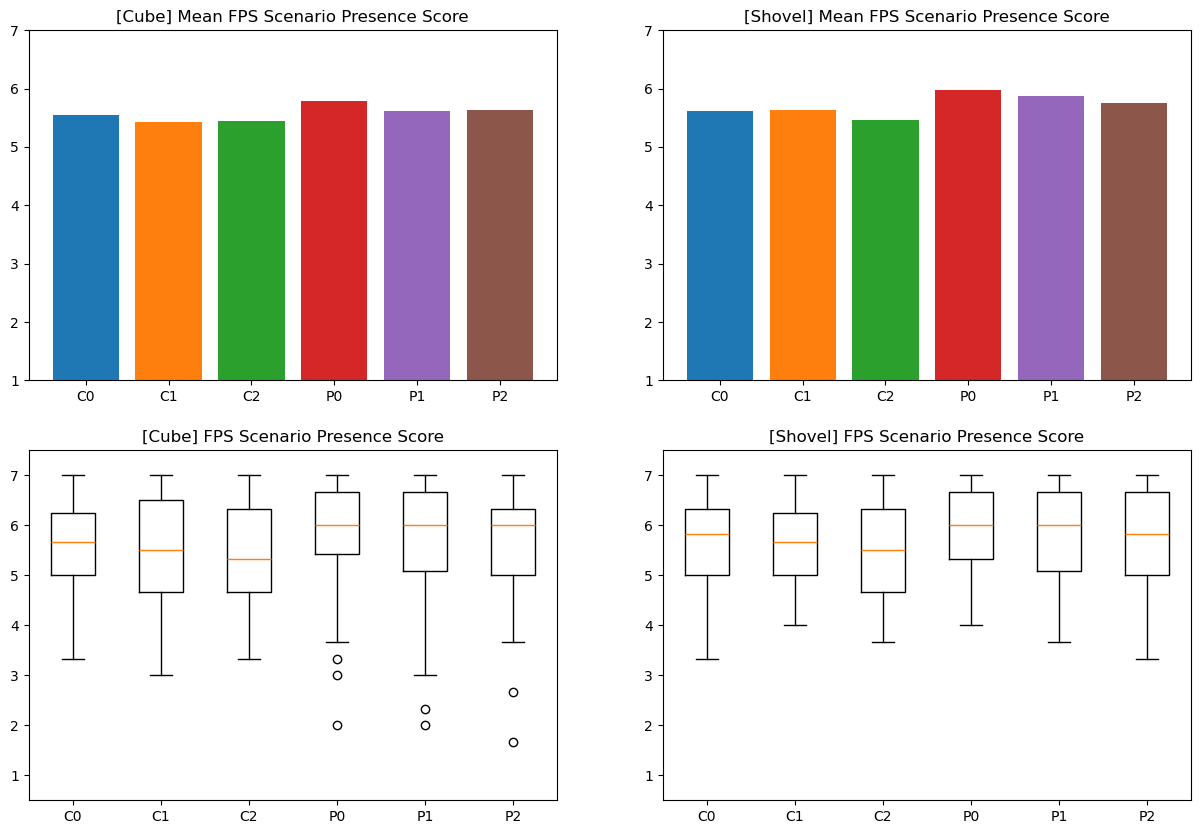

[Cube] FPS Scenario Presence Score


,sum_sq,df,F,PR(>F),Significance (p<0.05)
C(Device),2.682540,1.0,1.951800,0.163652,❌
C(Scaling),1.006173,2.0,0.366043,0.693850,❌
C(Device):C(Scaling),0.050265,2.0,0.018286,0.981881,❌
Residual,338.100529,246.0,NaN,NaN,❌


[Shovel] FPS Scenario Presence Score


,sum_sq,df,F,PR(>F),Significance (p<0.05)
C(Device),5.432540,1.0,5.456068,0.020305,✅
C(Scaling),1.597884,2.0,0.802402,0.449421,❌
C(Device):C(Scaling),0.137566,2.0,0.069081,0.933269,❌
Residual,244.939153,246.0,NaN,NaN,❌


In [293]:
fps_scenario = 'fps_scenario'
#Scenario Presence Score: (FPS-3 + FPS-4 + FPS-8) / 3
data[fps_scenario] = data.apply(lambda x: 
    (x[fps_3] + x[fps_4] + x[fps_8]) / 3,
    axis = 1)

title = 'FPS Scenario Presence Score'
score = fps_scenario
plot_experiments(data, score, title, range=[1,7])
two_way_anova(data, cube, score, title)
two_way_anova(data, shovel, score, title)

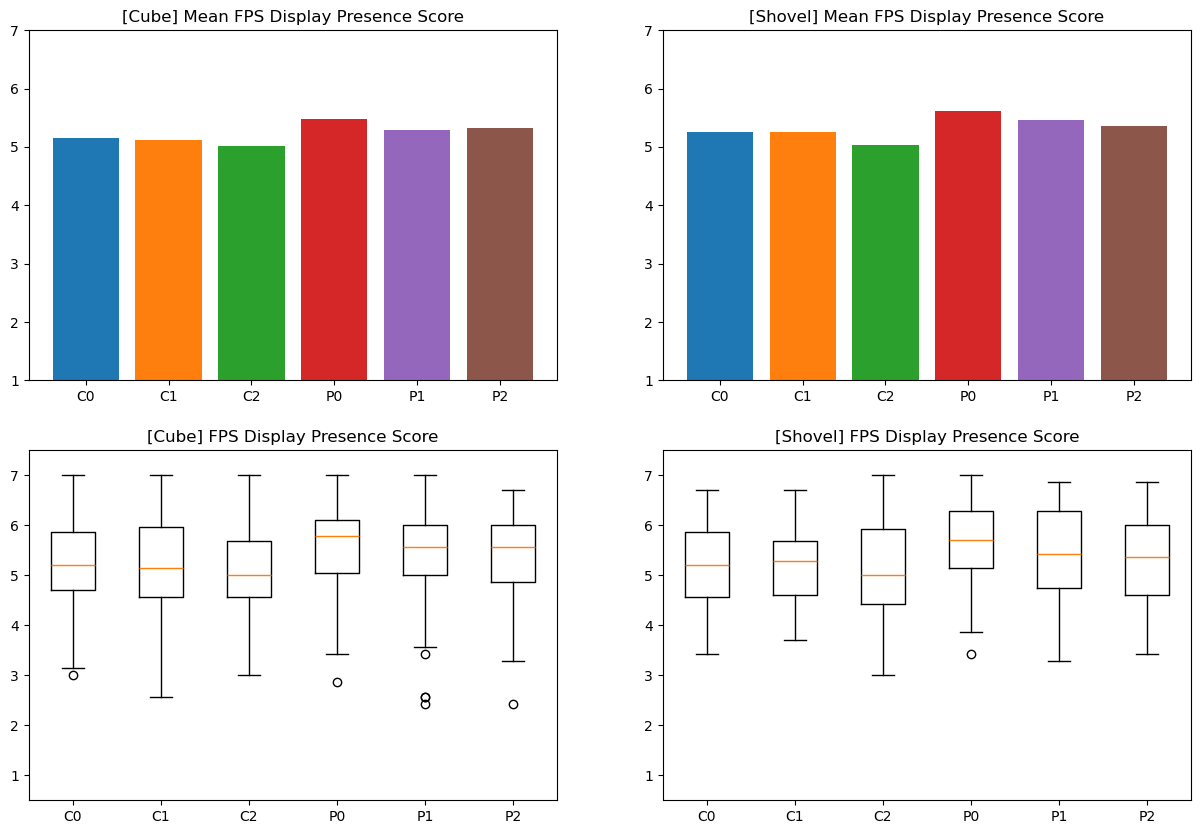

[Cube] FPS Display Presence Score


,sum_sq,df,F,PR(>F),Significance (p<0.05)
C(Device),4.587302,1.0,4.543613,0.034033,✅
C(Scaling),0.952543,2.0,0.471736,0.624482,❌
C(Device):C(Scaling),0.255750,2.0,0.126657,0.881093,❌
Residual,248.365403,246.0,NaN,NaN,❌


[Shovel] FPS Display Presence Score


,sum_sq,df,F,PR(>F),Significance (p<0.05)
C(Device),5.773324,1.0,6.920918,0.009057,✅
C(Scaling),2.429057,2.0,1.455947,0.235182,❌
C(Device):C(Scaling),0.275510,2.0,0.165137,0.847871,❌
Residual,205.209427,246.0,NaN,NaN,❌


In [294]:
fps_display = 'fps_display'
#Display Presence Score: (FPS-1 + FPS-2 + FPS-3 + FPS-4 +FPS-7 +FPS-8 + FPS-10) / 7
data[fps_display] = data.apply(lambda x: 
    (x[fps_1] + x[fps_2] + x[fps_3] + x[fps_4] + x[fps_7] + x[fps_8] + x[fps_10]) / 7,
    axis = 1)

title = 'FPS Display Presence Score'
score = fps_display
plot_experiments(data, score, title, range=[1,7])
two_way_anova(data, cube, score, title)
two_way_anova(data, shovel, score, title)

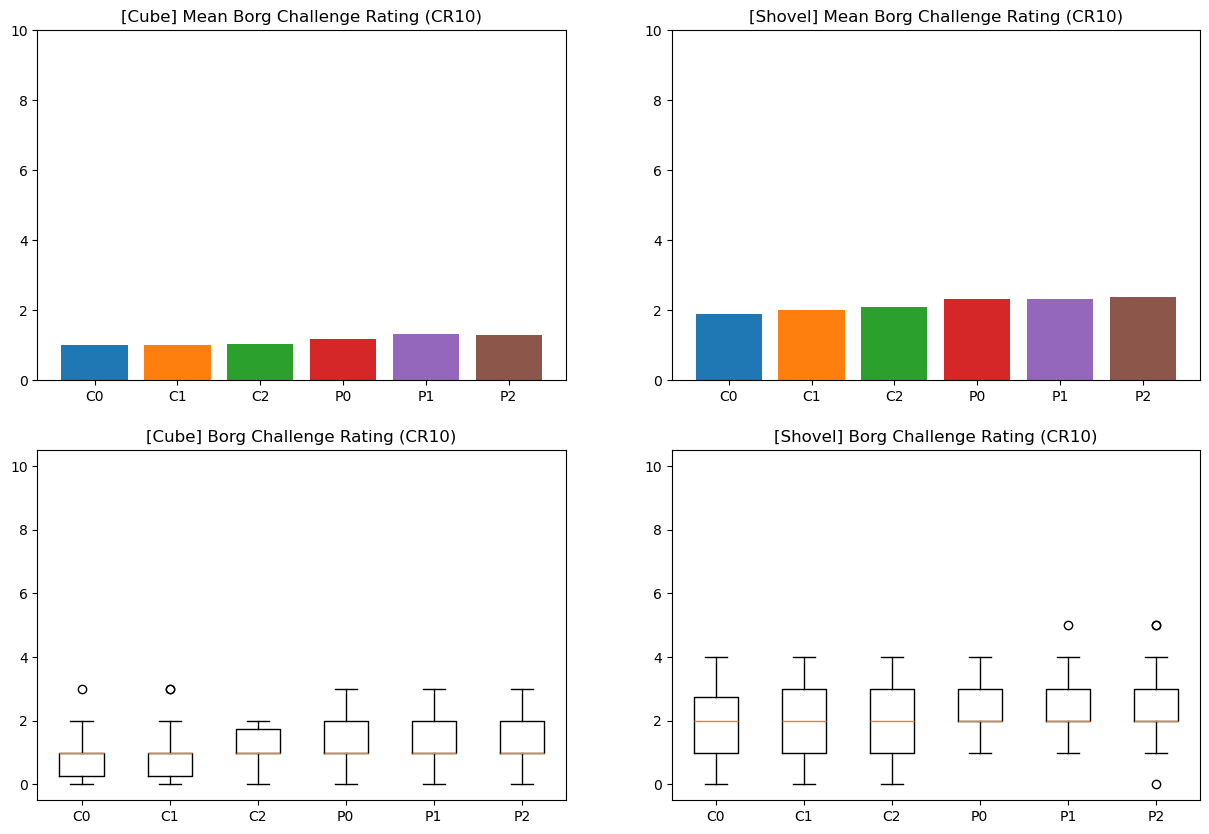

[Cube] Borg Challenge Rating (CR10)


,sum_sq,df,F,PR(>F),Significance (p<0.05)
C(Device),4.063492,1.0,6.907535,0.009123,✅
C(Scaling),0.341270,2.0,0.290063,0.748472,❌
C(Device):C(Scaling),0.293651,2.0,0.249589,0.779318,❌
Residual,144.714286,246.0,NaN,NaN,❌


[Shovel] Borg Challenge Rating (CR10)


,sum_sq,df,F,PR(>F),Significance (p<0.05)
C(Device),7.337302,1.0,7.294237,0.007398,✅
C(Scaling),0.722222,2.0,0.358992,0.698745,❌
C(Device):C(Scaling),0.150794,2.0,0.074954,0.927807,❌
Residual,247.452381,246.0,NaN,NaN,❌


In [295]:
borg_cr_numeric = 'borg_cr_numeric'
#Format: X(X) - ...
data[borg_cr_numeric] = data.apply(lambda x: int(x[borg_cr].split()[0]), axis = 1)

title = 'Borg Challenge Rating (CR10)'
score = borg_cr_numeric
plot_experiments(data, score, title, range=[0, 10])
two_way_anova(data, cube, score, title)
two_way_anova(data, shovel, score, title)

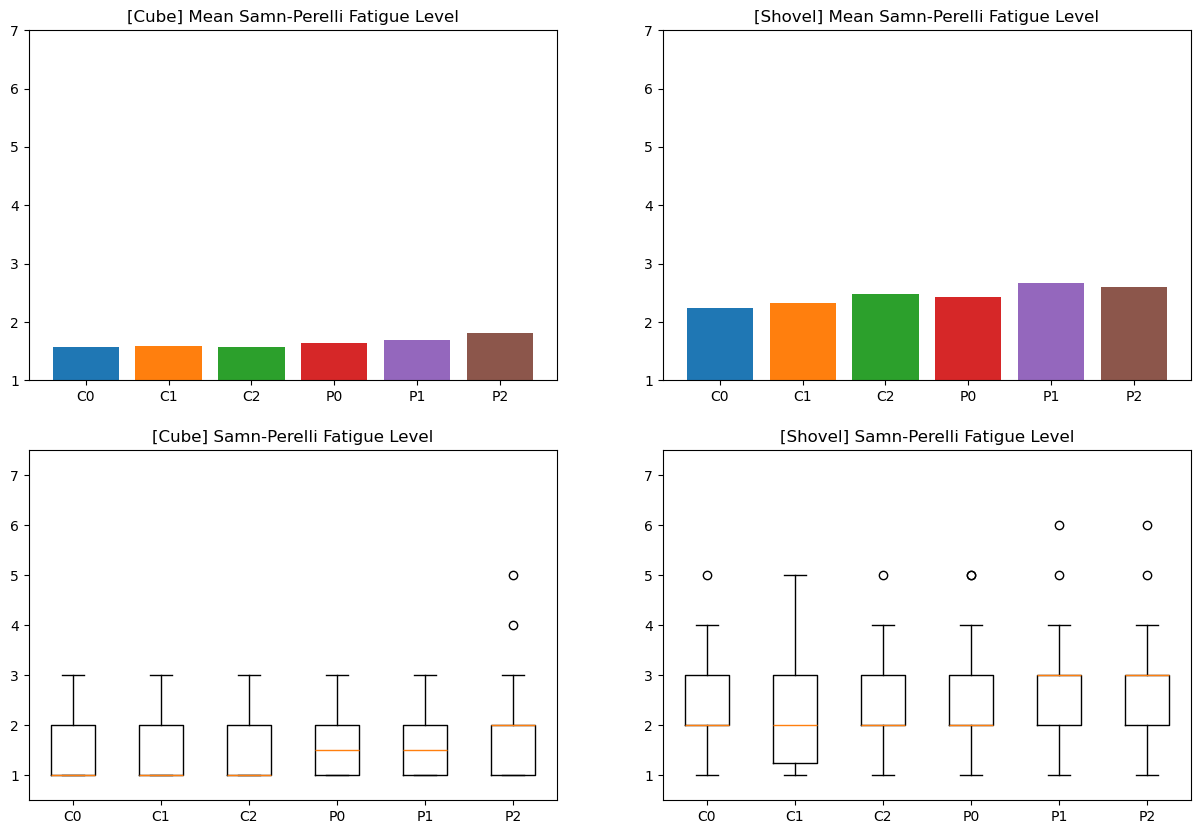

[Cube] Samn-Perelli Fatigue Level


,sum_sq,df,F,PR(>F),Significance (p<0.05)
C(Device),1.146825,1.0,1.883484,0.171189,❌
C(Scaling),0.293651,2.0,0.241138,0.785919,❌
C(Device):C(Scaling),0.341270,2.0,0.280242,0.755842,❌
Residual,149.785714,246.0,NaN,NaN,❌


[Shovel] Samn-Perelli Fatigue Level


,sum_sq,df,F,PR(>F),Significance (p<0.05)
C(Device),2.892857,1.0,2.316797,0.129268,❌
C(Scaling),1.960317,2.0,0.784978,0.457269,❌
C(Device):C(Scaling),0.500000,2.0,0.200217,0.818686,❌
Residual,307.166667,246.0,NaN,NaN,❌


In [296]:
sp_fatigue_numeric = 'sp_fatigue_numeric'
#Format: X - ...
data[sp_fatigue_numeric] = data.apply(lambda x: int(x[sp_fatigue].split()[0]), axis = 1)

title = 'Samn-Perelli Fatigue Level'
score = sp_fatigue_numeric
plot_experiments(data, score, title, range=[1,7])
two_way_anova(data, cube, score, title)
two_way_anova(data, shovel, score, title)

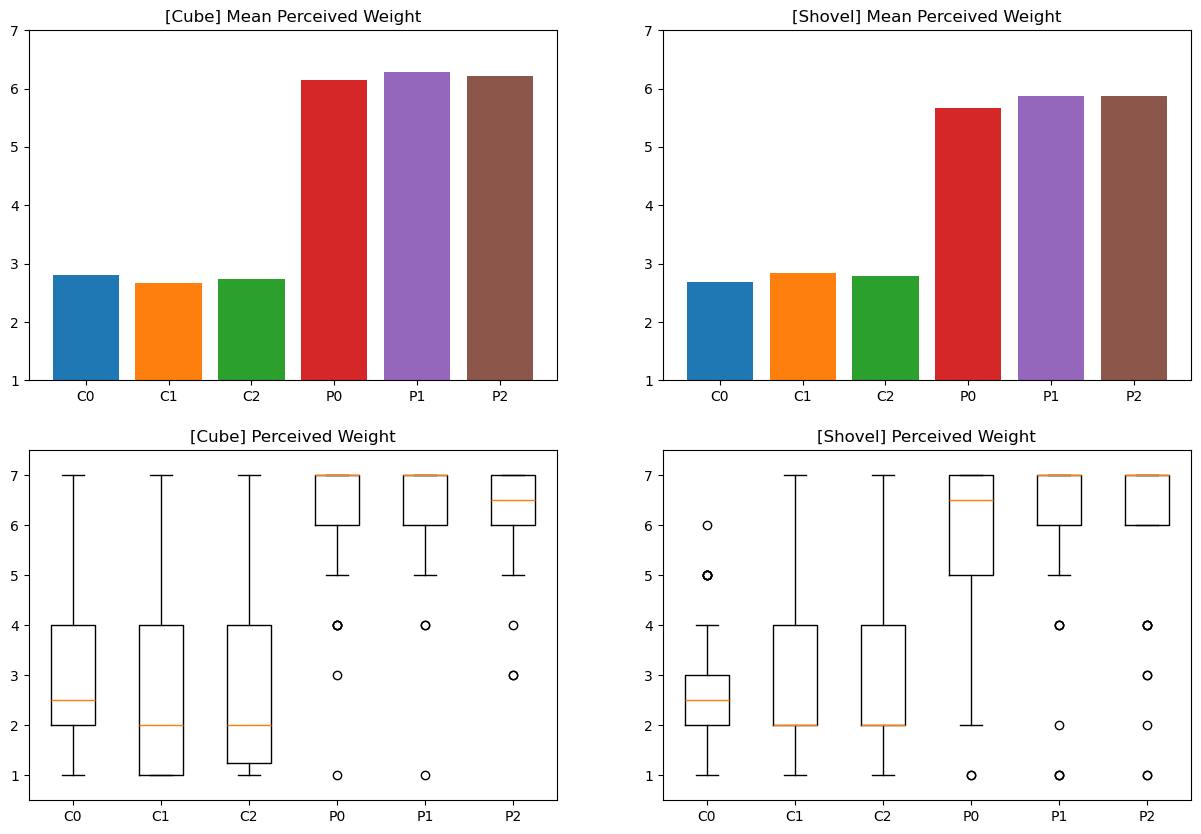

[Cube] Perceived Weight


,sum_sq,df,F,PR(>F),Significance (p<0.05)
C(Device),7.612857e+02,1.0,3.681365e+02,8.798990e-51,✅
C(Scaling),9.193635e-30,2.0,2.222892e-30,1.000000e+00,❌
C(Device):C(Scaling),8.571429e-01,2.0,2.072452e-01,8.129621e-01,❌
Residual,5.087143e+02,246.0,NaN,NaN,❌


[Shovel] Perceived Weight


,sum_sq,df,F,PR(>F),Significance (p<0.05)
C(Device),582.099206,1.0,207.523860,1.573788e-34,✅
C(Scaling),1.579365,2.0,0.281529,7.548716e-01,❌
C(Device):C(Scaling),0.150794,2.0,0.026880,9.734812e-01,❌
Residual,690.023810,246.0,NaN,NaN,❌


In [297]:
general_perceived_weight = 'general_perceived_weight'
data[general_perceived_weight] = data[general_1]

title = 'Perceived Weight'
score = general_perceived_weight
plot_experiments(data, score, title, range=[1,7])
two_way_anova(data, cube, score, title)
two_way_anova(data, shovel, score, title)

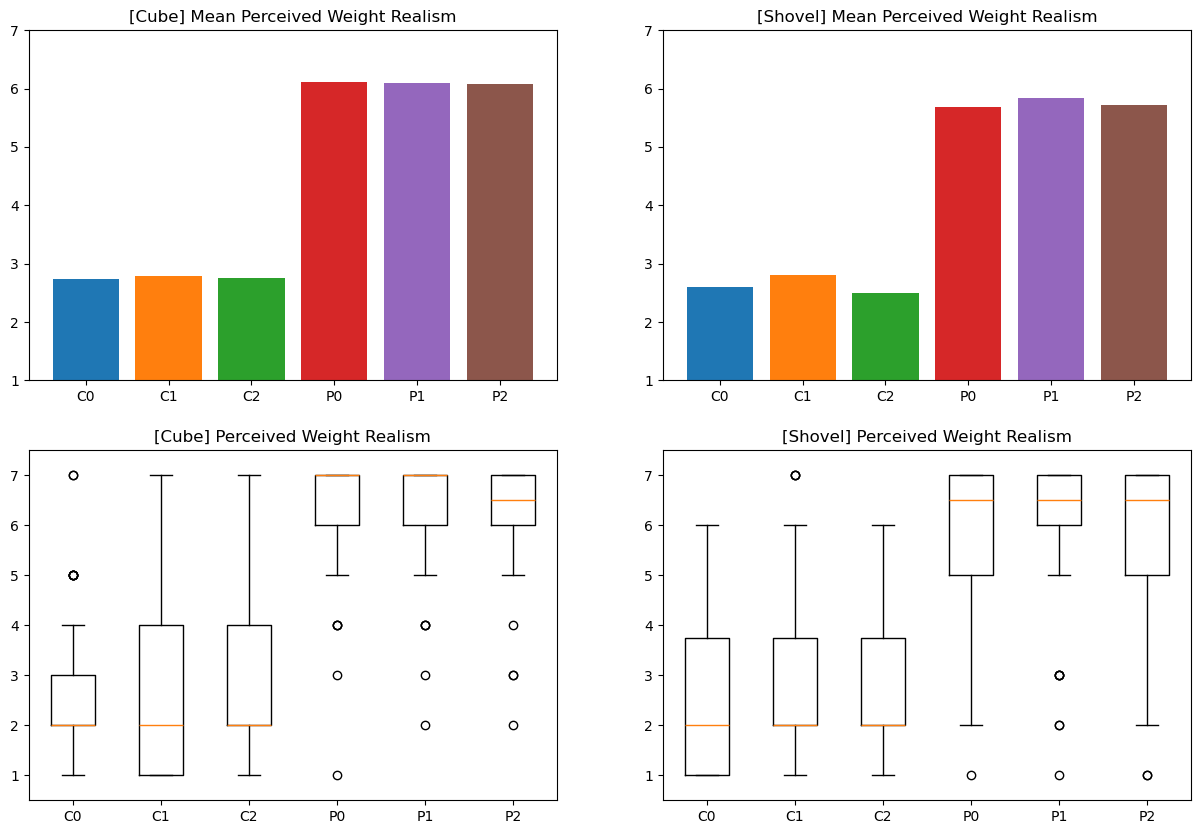

[Cube] Perceived Weight Realism


,sum_sq,df,F,PR(>F),Significance (p<0.05)
C(Device),700.000000,1.0,314.452174,6.997441e-46,✅
C(Scaling),0.023810,2.0,0.005348,9.946666e-01,❌
C(Device):C(Scaling),0.071429,2.0,0.016043,9.840856e-01,❌
Residual,547.619048,246.0,NaN,NaN,❌


[Shovel] Perceived Weight Realism


,sum_sq,df,F,PR(>F),Significance (p<0.05)
C(Device),609.777778,1.0,223.064155,2.448916e-36,✅
C(Scaling),2.214286,2.0,0.405006,6.674165e-01,❌
C(Device):C(Scaling),0.388889,2.0,0.071130,9.313598e-01,❌
Residual,672.476190,246.0,NaN,NaN,❌


In [298]:
general_perceived_weight_realism = 'general_perceived_weight_realism'
data[general_perceived_weight_realism] = data[general_2]

title = 'Perceived Weight Realism'
score = general_perceived_weight_realism
plot_experiments(data, score, title, range=[1,7])
two_way_anova(data, cube, score, title)
two_way_anova(data, shovel, score, title)

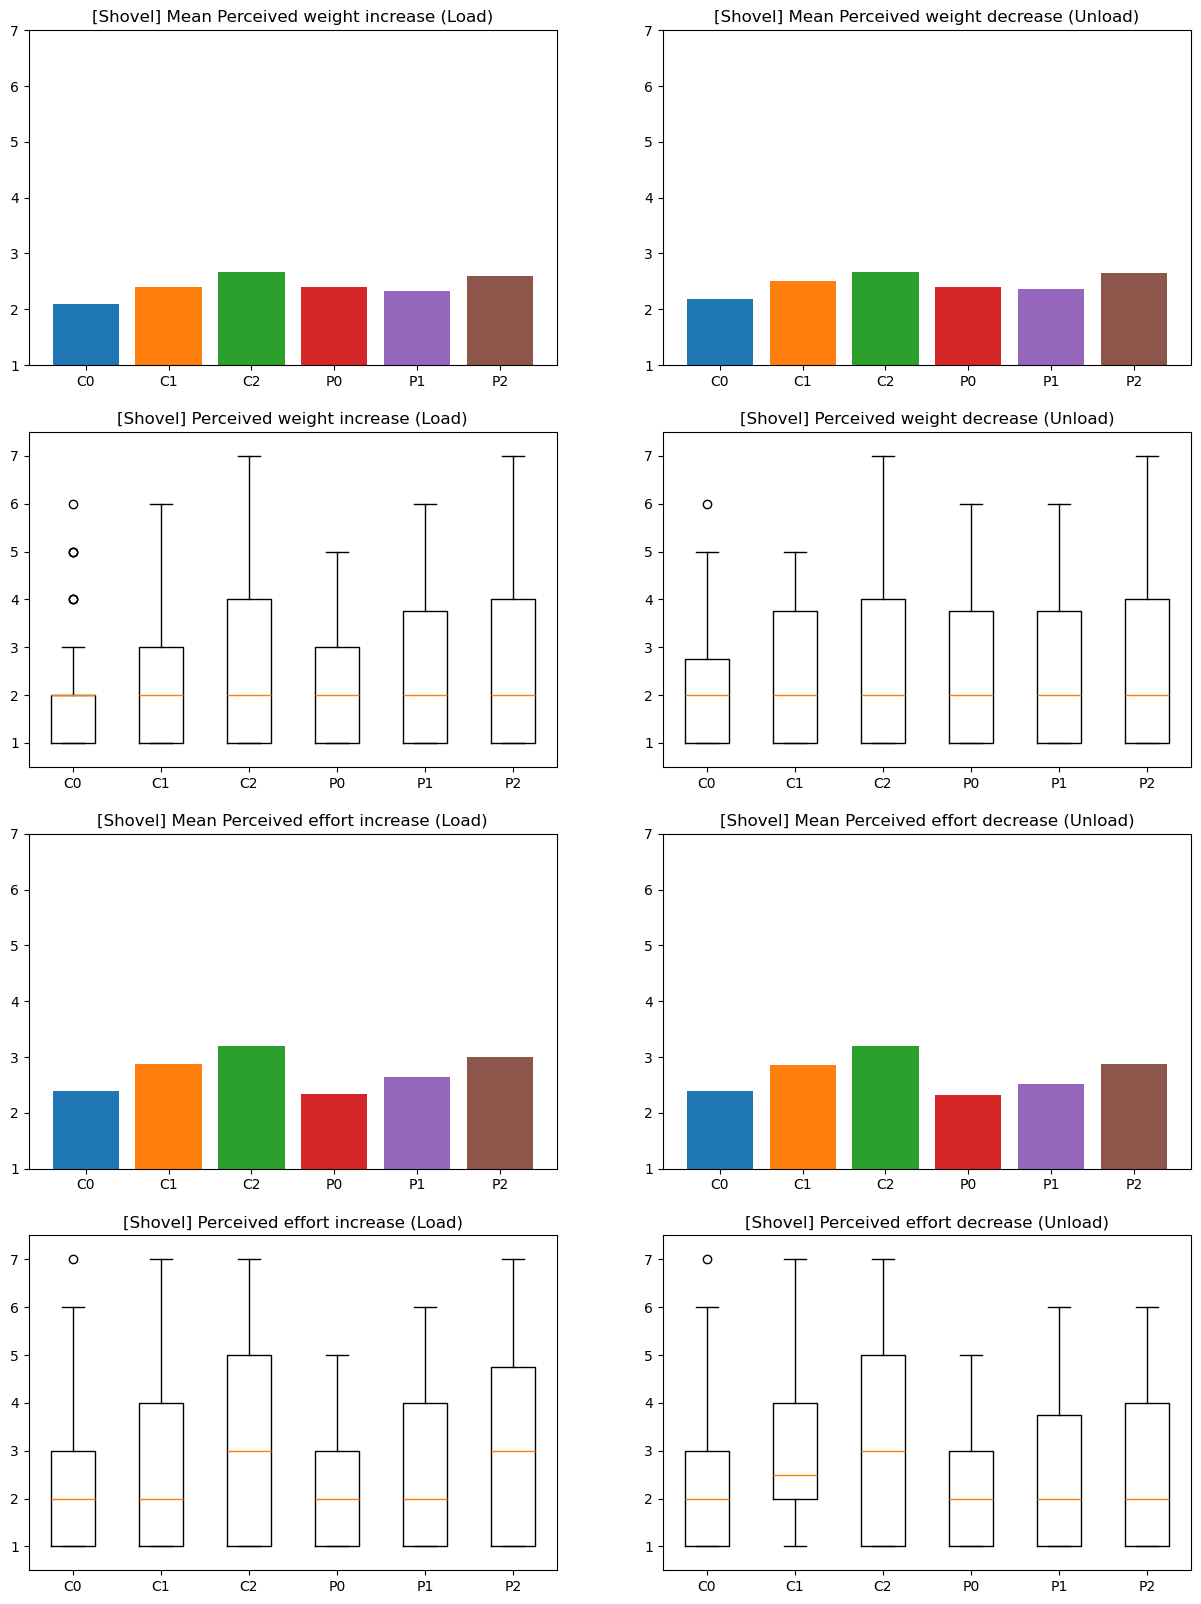

[Shovel] Perceived weight increase (Load)


,sum_sq,df,F,PR(>F),Significance (p<0.05)
C(Device),0.194444,1.0,0.078590,0.779453,❌
C(Scaling),6.380952,2.0,1.289520,0.277258,❌
C(Device):C(Scaling),2.031746,2.0,0.410593,0.663710,❌
Residual,608.642857,246.0,NaN,NaN,❌


[Shovel] Perceived weight decrease (Unload)


,sum_sq,df,F,PR(>F),Significance (p<0.05)
C(Device),0.015873,1.0,0.006667,0.934992,❌
C(Scaling),5.484127,2.0,1.151667,0.317808,❌
C(Device):C(Scaling),1.388889,2.0,0.291667,0.747275,❌
Residual,585.714286,246.0,NaN,NaN,❌


[Shovel] Perceived effort increase (Load)


,sum_sq,df,F,PR(>F),Significance (p<0.05)
C(Device),1.587302,1.0,0.502051,0.479271,❌
C(Scaling),22.952381,2.0,3.629829,0.027951,✅
C(Device):C(Scaling),0.412698,2.0,0.065267,0.936834,❌
Residual,777.761905,246.0,NaN,NaN,❌


[Shovel] Perceived effort decrease (Unload)


,sum_sq,df,F,PR(>F),Significance (p<0.05)
C(Device),3.571429,1.0,1.300853,0.255167,❌
C(Scaling),20.023810,2.0,3.646725,0.027496,✅
C(Device):C(Scaling),0.880952,2.0,0.160439,0.851859,❌
Residual,675.380952,246.0,NaN,NaN,❌


In [299]:


shovel_load_weight = 'shovel_load_weight'
data[shovel_load_weight] = data[shovel_1]

shovel_unload_weight = 'shovel_unload_weight'
data[shovel_unload_weight] = data[shovel_2]

shovel_load_effort = 'shovel_load_effort'
data[shovel_load_effort] = data[shovel_3]

shovel_unload_effort = 'shovel_unload_effort'
data[shovel_unload_effort] = data[shovel_4]

scale = [1,7]

fig, axs = plt.subplots(4, 2, figsize=(15, 20))

shovel_load_weight_title = 'Perceived weight increase (Load)'
plot_means(data, shovel_load_weight, shovel, shovel_load_weight_title, scale, axs[0,0])
plot_boxplot(data, shovel_load_weight, shovel, shovel_load_weight_title, scale, axs[1,0])

shovel_unload_weight_title = 'Perceived weight decrease (Unload)'
plot_means(data, shovel_unload_weight, shovel, shovel_unload_weight_title, scale, axs[0,1])
plot_boxplot(data, shovel_unload_weight, shovel, shovel_unload_weight_title, scale, axs[1,1])

shovel_load_effort_title = 'Perceived effort increase (Load)'
plot_means(data, shovel_load_effort, shovel, shovel_load_effort_title, scale, axs[2,0])
plot_boxplot(data, shovel_load_effort, shovel, shovel_load_effort_title, scale, axs[3,0])

shovel_unload_effort_title = 'Perceived effort decrease (Unload)'
plot_means(data, shovel_unload_effort, shovel, shovel_unload_effort_title, scale, axs[2,1])
plot_boxplot(data, shovel_unload_effort, shovel, shovel_unload_effort_title, scale, axs[3,1])

plt.show()

two_way_anova(data, shovel, shovel_load_weight, shovel_load_weight_title)
two_way_anova(data, shovel, shovel_unload_weight, shovel_unload_weight_title)
two_way_anova(data, shovel, shovel_load_effort, shovel_load_effort_title)
two_way_anova(data, shovel, shovel_unload_effort, shovel_unload_effort_title)